# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [67]:
# Your comment here

# I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment.
# All work submitted is my own and reflects my understanding of the material.


## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [68]:
# Your code here 
import numpy as np 
import matplotlib.pyplot as plt
#import solve_ivp as 

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [69]:
# Your code here
g = 9.81 #m/s^2
l = 1 #meter

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [70]:
# Your code here

def pendulum(t, y):
    theta, omega = y # y position
    dtheta_dt = omega
    domega_dt = -(g / l) * np.sin(theta)
    return dtheta_dt, domega_dt

Give you equation some initial conditions. Run the cell below.

In [71]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity
y0 = [theta_0, omega_0]


Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [72]:
# Your code here

from scipy.integrate import solve_ivp

t_span = (0, 10) # sim from t=0 to 10 seconds
t_eval = np.linspace(0,10,11)  # evaluate

sol = solve_ivp(pendulum, t_span, y0, t_eval=t_eval)


Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [73]:
# Your code here

time_values = sol.t          
theta_values = sol.y[0, :] 


Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [74]:
# Your code here

period = 2 * np.pi * np.sqrt(l / g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [75]:
# Your code here

print(np.round(period, 2))

2.01


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [76]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

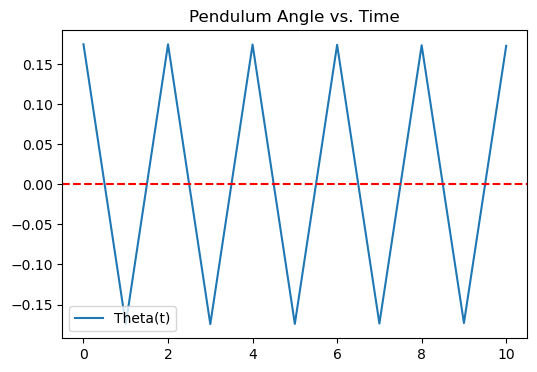

In [77]:
# Your code here

plt.figure(figsize=(6,4))

plt.plot(time_values, theta_values, label="Theta(t)")

plt.axhline(y=0, color="red", linestyle="--")

plt.x_label = 'Time (s)'
plt.y_label = 'Theta (radians)'
plt.title("Pendulum Angle vs. Time")
plt.legend()

plt.show()

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [78]:
# Your code here
print('Numerical Period:', np.round(T_numerical, 4))

print('Theoretical Period:', np.round(period, 4))

Numerical Period: 2.0
Theoretical Period: 2.0061


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [79]:
# Your comment here

#The Approximation almost perfectly matches the numerical result. Our model seems to be highly accurate. 

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [80]:
# Your code here

import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [81]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [82]:
# Your code here
df = pd.read_csv(url)


Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [83]:
# Your code here

df_country = df[df["location"] == "United States"]

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [84]:
# Your code here

#drop rest
df_country = df_country[["date", "total_cases"]].dropna()

#add column
df_country["days_since_start"] = range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [85]:
# Your code here

df_country.head()

,date,total_cases,days_since_start
403451,2020-01-05,0.0,0
403452,2020-01-06,0.0,1
403453,2020-01-07,0.0,2
403454,2020-01-08,0.0,3
403455,2020-01-09,0.0,4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [86]:
# Your code here

from scipy.optimize import curve_fit
import numpy as np

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [87]:
# Your code here

def exponential_growth(t, C_0, r):
    return C_0 * np.e**(r * t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [97]:
# Your code here

days = df_country["days_since_start"][:30].values
cases = df_country["total_cases"][:30].values

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [98]:
# Your code here

p0 = [1, 0.1]
popt, pcov = curve_fit(exponential_growth, days, cases, p0=p0)


Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [99]:
# Your code here
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [100]:
# Your code here

print(f"Best-fit C0 = {C0_fit:.2g}")
print(f"Best-fit r  = {r_fit:.4g}")

Best-fit C0 = 0.12
Best-fit r  = 0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [101]:
# Your code here

import matplotlib.pyplot as plt

future_days = np.arange(61)


Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [102]:
# Your code here 

predicted_cases = exponential_growth(future_days, C0_fit, r_fit)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

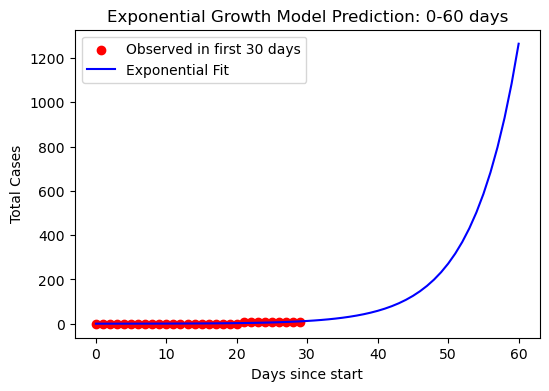

In [103]:
# Your code here

plt.figure(figsize=(6,4))

plt.scatter(days, cases, label='Observed in first 30 days', color='red')

plt.plot(future_days, predicted_cases, label='Exponential Fit', color='blue')

plt.xlabel("Days since start")
plt.ylabel("Total Cases")
plt.title("Exponential Growth Model Prediction: 0-60 days")
plt.legend()

plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [104]:
# Your comment here

# We only have points up to 30 days as thats what we were asked to take from the data set, but the model seems to fit it decently will, with the shallow rise covered by the exponential line.


Make another plot but this time to **90 days**.

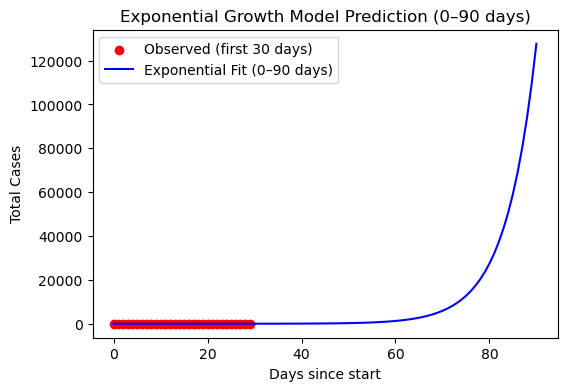

In [105]:
# Your code here

# 90 array
future_days_90 = np.arange(91)

# models predictions
predicted_cases_90 = exponential_growth(future_days_90, C0_fit, r_fit)

# plot
plt.figure(figsize=(6,4))
plt.scatter(days, cases, color='red', label='Observed (first 30 days)')
plt.plot(future_days_90, predicted_cases_90, color='blue', label='Exponential Fit (0–90 days)')

plt.xlabel("Days since start")
plt.ylabel("Total Cases")
plt.title("Exponential Growth Model Prediction (0–90 days)")
plt.legend()
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [107]:
# Your code here

#prediction @ 87
cases_day_87 = exponential_growth(87, C0_fit, r_fit)
print(f"Predicted number of cases at 87 days = {cases_day_87:.2f}")

#looks to be pretty accurate, 80,000 mark around 84 days

Predicted number of cases at 87 days = 80497.12


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

In [112]:
# Your code here

import seaborn as sns
from scipy.stats import linregress # for plot


In [121]:
diamonds = sns.load_dataset('diamonds')
print(diamonds.head())


   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


Text(0.5, 1.0, 'Diamonds dataset: Price vs. Carat colored by Cut')

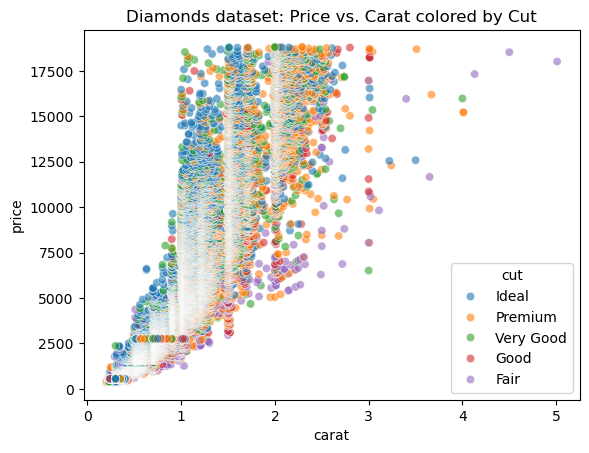

In [122]:
#scatterplot w/ seaborn

plot1 = sns.scatterplot(data=diamonds, x="carat", y="price", hue="cut", alpha=0.6)
plot1.set_title("Diamonds dataset: Price vs. Carat colored by Cut")

In [123]:
#extracting price and carat data 

x = diamonds["carat"]
y = diamonds["price"]

In [141]:
#fitting
slope, intercept, r_value, p_value, std_err = linregress(x, y)


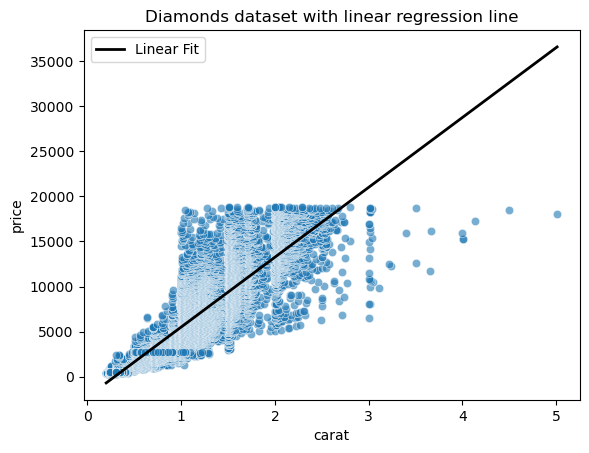

In [142]:
xfit = np.linspace(x.min(), x.max(), 200)
yfit = slope * xfit + intercept

plt.figure()

# Scatter‐plot the data again
plot2 = sns.scatterplot(data=diamonds, x="carat", y="price", alpha=0.6)
plot2.set_title("Diamonds dataset with linear regression line")

# Overlay the regression line
sns.lineplot(x=xfit, y=yfit, color="black", linewidth=2, label="Linear Fit", ax=plot2)

plt.legend()
plt.show()

On it's own branch, submit this notebook to Gradescope! 